# Modelling Galaxy Populations


In [1]:
from astropy.cosmology import Planck18 as cosmo
from astropy.cosmology import z_at_value
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from synthesizer.grid import Grid
from synthpop import GalaxyPopulation
from synthpop.models import Model, Default, Constant, Spheroid
from unyt import yr, Myr, Msun, Gyr, unyt_quantity, Mpc, dimensionless


## Initialisation

In [2]:
# load grid
grid = Grid("test_grid")

# load default model
model = Default()
model = Constant()

# Define the volume of the galaxy population
volume = 1E6 * Mpc**3

In [3]:

# Instantiate the galaxy population
galpop = GalaxyPopulation(
    minimum_stellar_mass=1E8*Msun, 
    maximum_stellar_mass=1E11*Msun, 
    volume=volume,
    model=model,
    grid=grid,
    cosmology=cosmo,
    redshift=0.0,
    random_seed=42)

print(galpop)




----------
SUMMARY OF GALAXY POPULATION
Number of galaxies: 37036
Volume: 1.00e+06 Mpc**3
Redshift: 0.0
Total stellar mass density: 1.82e+08 Msun/Mpc**3
Range of stellar masses: 1.00e+08 - 9.98e+10
Age of the universe at z=0.0: 1.38e+04 Myr
----------



## Useful methods and plots

### Galaxy stellar mass function

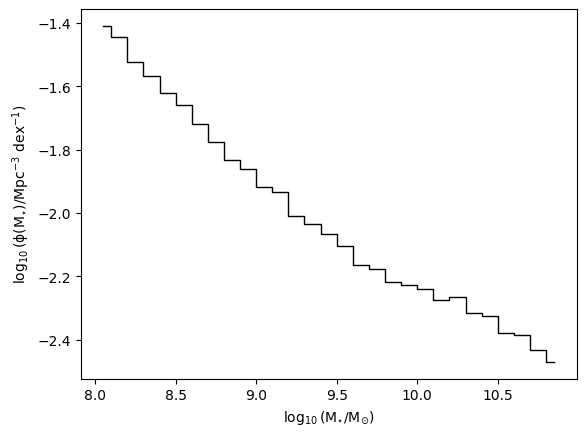

In [4]:
galpop.plot_stellar_mass_function()

### Dust attenuation

Because the chosen model predicts the dust attenuation experienced by individual galaxies, we can investigate how dust attenuation varies as a function of stellar mass. The figure below illustrates the predicted relationship between these two quantities.

In [5]:
plt.scatter(galpop.surviving_masses.to("Msun"), galpop.tau_v, s=1)
plt.xscale('log')
plt.xlabel(r'$M_\star\ (M_\odot)$')
plt.ylabel(r'$\tau_V$')
plt.show()

AttributeError: 'GalaxyPopulation' object has no attribute 'tau_v'

### Star formation rate distribution function

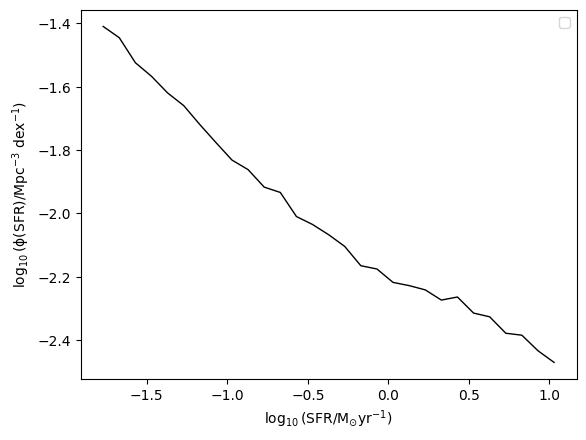

In [6]:
galpop.plot_star_formation_rate_distribution_function()

### Stellar mass vs. (specific) star formation rate 

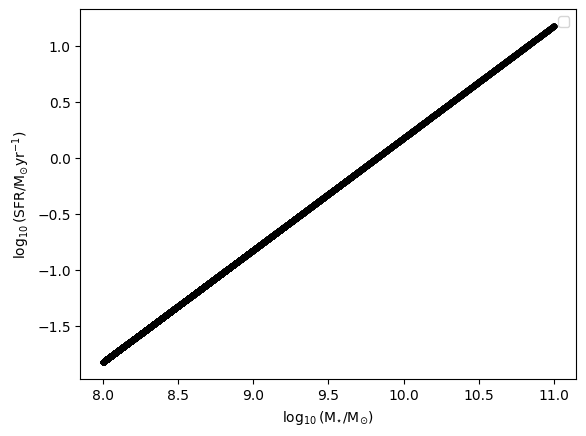

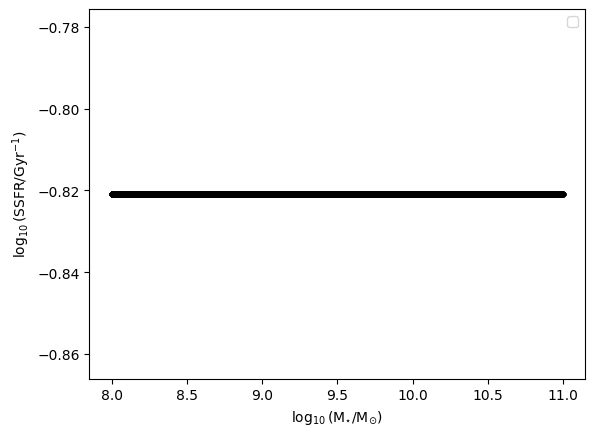

In [7]:
galpop.plot_sfr_vs_stellar_mass()
galpop.plot_ssfr_vs_stellar_mass()

### Star formation histories

Methods are also provided to plot either combined or individual star formation histories. By default, these display the stellar mass formed in each time bin; however, the star formation rate per bin can also be plotted as an alternative.

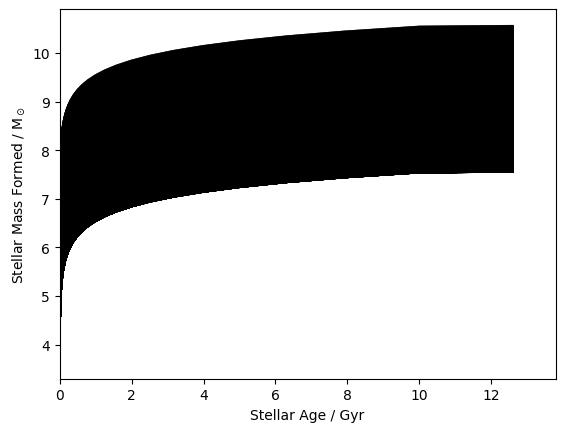

In [8]:

# Plot all star formation histories (SFHs) for the galaxy population. 
galpop.plot_sfhs(N='all')


# # Plot the combined SFH for the galaxy population. 
# galpop.plot_sfh()

# # Plot the combined star formation history using the rate.
# galpop.plot_sfh(rate=True)


## Combining galaxy populations

In [9]:
# Instantiate the galaxy population using the Spheroid model
spheroid_pop = GalaxyPopulation(
    minimum_stellar_mass=1E8*Msun, 
    maximum_stellar_mass=1E11*Msun, 
    volume=volume,
    model=Spheroid(),
    grid=grid,
    cosmology=cosmo,
    redshift=0.0,
    random_seed=42)


## Saving and loading GalaxyPopulation

The GalaxyPopulation class includes the functionality to dump as a pickle file and reload it later.

In [10]:
galpop.save("galaxy_population.pkl")

del galpop

# Load the galaxy population from the pickle file
galpop = GalaxyPopulation.load("galaxy_population.pkl")
print(galpop)

----------
SUMMARY OF GALAXY POPULATION
Number of galaxies: 37036
Volume: 1.00e+06 Mpc**3
Redshift: 0.0
Total stellar mass density: 1.82e+08 Msun/Mpc**3
Range of stellar masses: 1.00e+08 - 9.98e+10
Age of the universe at z=0.0: 1.38e+04 Myr
----------



## Project galaxy population to earlier time

In [11]:
galpop_at_earlier_epoch = galpop.project_to_earlier_epoch(redshift=3.0)

print(galpop)
print(galpop_at_earlier_epoch)

----------
SUMMARY OF GALAXY POPULATION
Number of galaxies: 37036
Volume: 1.00e+06 Mpc**3
Redshift: 0.0
Total stellar mass density: 1.82e+08 Msun/Mpc**3
Range of stellar masses: 1.00e+08 - 9.98e+10
Age of the universe at z=0.0: 1.38e+04 Myr
----------

----------
SUMMARY OF GALAXY POPULATION
Number of galaxies: 37036
Volume: 1.00e+06 Mpc**3
Redshift: 3.0
Total stellar mass density: 3.41e+07 Msun/Mpc**3
Range of stellar masses: 1.87e+07 - 1.87e+10
Age of the universe at z=3.0: 2.14e+03 Myr
----------



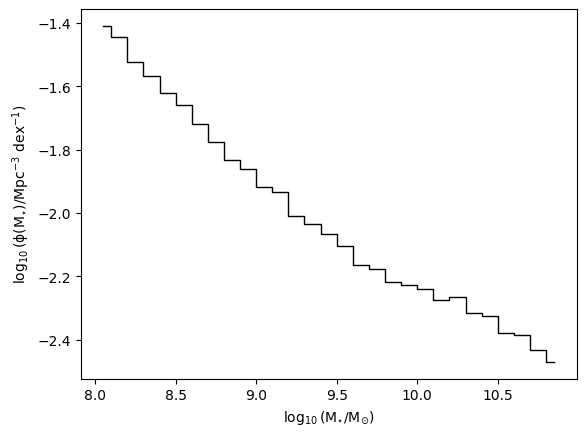

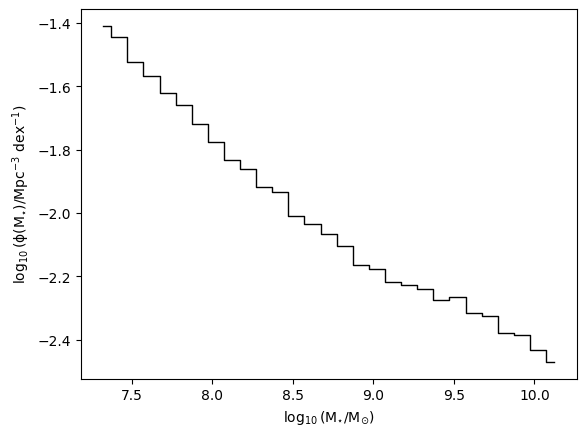

In [12]:

galpop.plot_stellar_mass_function()
galpop_at_earlier_epoch.plot_stellar_mass_function()
